In [1]:
import os
import re
import emcee
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
import astropy.units as u
from astropy.io import fits
from scipy.special import wofz
from scipy.signal import convolve
from scipy.optimize import minimize
from linetools.spectra.lsf import LSF

In [2]:
target_directory = Path().resolve()
dla_directories = sorted([d for d in os.listdir(target_directory) if d.startswith("G130M_1291") or d.startswith("E140M")])
print(dla_directories)
galaxy = target_directory.parts[target_directory.parts.index('float-for-morrow') + 1]

['G130M_1291_LP5_2062.400_16812']


In [3]:
def parse_directory(dirname):

    Target = target_directory.name

    parts = dirname.split("_")

    Grating = parts[0]
    Cenwave = int(parts[1])
    T_exp = str(parts[3])
    PID = int(parts[4])

    if Grating.startswith("G"):
        
        Instrument = "COS"
        LP = parts[2]

        return {
            "Target": Target, 
            "Instrument": Instrument, 
            "Grating": Grating, 
            "Cenwave": Cenwave, 
            "LP": LP, 
            "Aperture": None, 
            "T_exp": T_exp, 
            "PID": PID, 
        }
        
    else:
        
        Instrument = "STIS"
        Aperture = parts[2]
        return {
            "Target": Target, 
            "Instrument": Instrument, 
            "Grating": Grating, 
            "Cenwave": Cenwave, 
            "LP": None, 
            "Aperture": Aperture, 
            "T_exp": T_exp, 
            "PID": PID, 
        }

records = [parse_directory(d) for d in dla_directories]
df = pd.DataFrame.from_records(records)
display(df)

,Target,Instrument,Grating,Cenwave,LP,Aperture,T_exp,PID
0,BAT99 113,COS,G130M,1291,LP5,None,2062.400,16812


In [4]:
def voigt(delta_lambda, sigma, gamma):
    z = (delta_lambda + 1j * gamma) / (sigma * np.sqrt(2))
    return wofz(z).real / (sigma * np.sqrt(2 * np.pi))

def S_II_doublet_profile(wave, logN, b, z):
    
    N = 10.0 ** logN
    c = 2.9979e5
    
    lines = [
        {'lam0': 1250.584, 'f': 0.00543, 'gamma': 1.15e9},
        {'lam0': 1253.811, 'f': 0.0109, 'gamma': 1.09e9}
    ]
    
    tau_total = np.zeros_like(wave)
    
    for line in lines:
        lam_obs = line['lam0'] * (1.0 + z)
        
        sigma = (lam_obs * b) / (c * np.sqrt(2))
        
        gamma_lam = (line['gamma'] * (lam_obs ** 2)) / (4 * np.pi * 2.9979e18)

        profile = voigt(wave - lam_obs, sigma, gamma_lam)
        tau_total += 8.85e-13 * N * line['f'] * (lam_obs ** 2 / 1e8) * profile

    return tau_total

In [5]:
def model_spectrum(wave, continuum, logN, b, z, lsf):
    
    tau = S_II_doublet_profile(wave, logN, b, z)

    model = continuum * np.exp(-tau)
    model = convolve(model, lsf["kernel"], mode = "same")
    
    return model

In [6]:
def fit_hi_columns_mcmc(i, wave, flux, err, cont_windows, fit_windows):

    Grating = df["Grating"].tolist()[i]
    if Grating.startswith("G"):
        lsf_obj = LSF(dict(name = df["Instrument"].tolist()[i], grating = df["Grating"].tolist()[i], life_position = str(df["LP"].tolist()[i].lstrip("LP")), cen_wave = str(df["Cenwave"].tolist()[i])))
        lsf = lsf_obj.interpolate_to_wv_array(wave * u.AA, kind = 'cubic') # Akima is troublesome for COS
    else:
        lsf_obj = LSF(dict(name = df["Instrument"].tolist()[i], grating = df["Grating"].tolist()[i], slit = str(df["Aperture"].tolist()[i]), cen_wave = str(df["Cenwave"].tolist()[i])))
        lsf = lsf_obj.interpolate_to_wv_array(wave * u.AA, kind = 'cubic')

    cont_mask = np.zeros_like(wave, dtype = bool)
    for bounds in cont_windows:
        cont_mask |= (wave >= bounds[0]) & (wave <= bounds[1])
    continuumfit = np.polyfit(wave[cont_mask], flux[cont_mask], 1) # Linear continuum
    cont = np.polyval(continuumfit, wave)

    flux_mask = np.zeros_like(wave, dtype = bool)
    for bounds in fit_windows:
        flux_mask |= (wave >= bounds[0]) & (wave <= bounds[1])
    masked_wave, masked_flux, masked_err, masked_cont = wave[flux_mask], flux[flux_mask], err[flux_mask], cont[flux_mask]

    def log_prob(x): # assuming Gaussian density, using https://emcee.readthedocs.io/en/stable/tutorials/quickstart/#quickstart

        logN, b, z = x

        if not (14.0 <= logN <= 22.0 and 0 <= b <= 30 and 0 <= z <= 0.001): # prior cutoff range for both systems
            return -np.inf

        model = model_spectrum(masked_wave, masked_cont, logN, b, z, lsf)
        res = (masked_flux - model) / masked_err
        log_likelihood = -0.5 * np.sum(res ** 2)

        return log_likelihood

    ndim, nwalkers = 3, 100
    p0 = np.empty((nwalkers, ndim))
    p0[:, 0] = np.random.uniform(14.0, 16.0, nwalkers)
    p0[:, 1] = np.random.uniform(0, 10.0, nwalkers) # initial guess
    p0[:, 2] = np.random.uniform(0, 0.001, nwalkers) # initial guess
    sampler = emcee.EnsembleSampler(nwalkers, ndim, log_prob)
    state = sampler.run_mcmc(p0, 100) # burn-in
    sampler.reset()
    sampler.run_mcmc(p0, 1000, progress = True);

    flat_samples = sampler.get_chain(flat = True)
    best_idx = np.argmax([log_prob(x) for x in flat_samples])
    best_logN, best_b, best_z = flat_samples[best_idx]

    err_logN = 0.5 * (np.percentile(flat_samples[:, 0], 84) - np.percentile(flat_samples[:, 0], 16)) # estimate standard error by looking for the middle 68%
    err_b = 0.5 * (np.percentile(flat_samples[:, 1], 84) - np.percentile(flat_samples[:, 1], 16))
    err_z = 0.5 * (np.percentile(flat_samples[:, 2], 84) - np.percentile(flat_samples[:, 2], 16))
    best_model = model_spectrum(wave, cont, best_logN, best_b, best_z, lsf)

    plt.figure(figsize=(8, 5))
    plt.hist(flat_samples[:, 0], bins=100, histtype="step", color="k", lw=2)
    plt.axvline(best_logN, color="r", linestyle="--", label=f"Best fit: {best_logN:.2f}")
    plt.xlabel(r"$\log N$ (cm$^{-2}$)")
    plt.ylabel("Frequency")
    plt.title("Posterior Distribution of Column Density")
    plt.legend()
    plt.show()

    return best_logN, best_b, best_z, err_logN, err_b, err_z, cont, best_model

100%|███████████████████████████████████████| 1000/1000 [00:30<00:00, 32.40it/s]


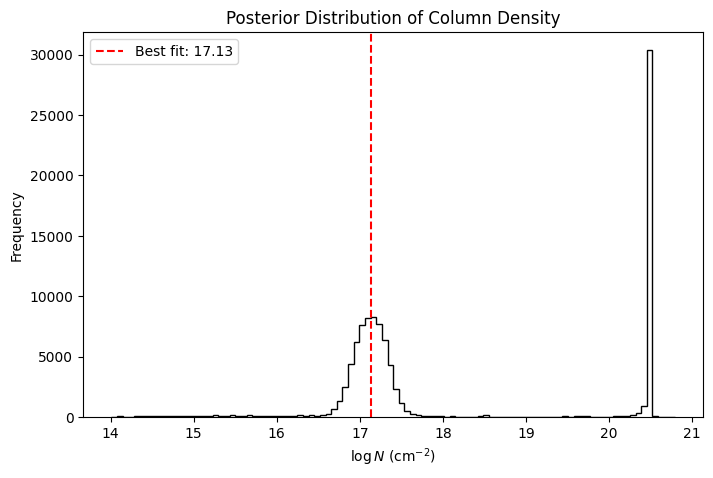

In [7]:
records = []

heliocentric_velocities_path = os.path.join(target_directory, "heliocentric_velocities.txt")

with open(heliocentric_velocities_path, "r") as file:
    lines = file.readlines()
    z_mw = float(lines[0].strip())
    z_sys = float(lines[1].strip())

cont_windows = [[1251.0, 1251.2], [1252.2, 1252.4]]
fit_windows = [[1251.2, 1252.2]]

for i in range(len(dla_directories)):

    directory = dla_directories[i]
    path = target_directory / directory

    for file in os.listdir(path):
        if file.endswith("_x1dsum.fits") or file.endswith("_x1d.fits"):

            src = path / file

            hdul = fits.open(src)
            wave = np.concatenate(hdul[1].data["WAVELENGTH"])
            flux = np.concatenate(hdul[1].data["FLUX"])
            err  = np.concatenate(hdul[1].data["ERROR"])

            sorted_indices = np.argsort(wave)
            wave = wave[sorted_indices]
            flux = flux[sorted_indices]
            err = err[sorted_indices]

            best_logN, best_b, best_z, err_logN, err_b, err_z, cont, best_model = fit_hi_columns_mcmc(i, wave, flux, err, cont_windows, fit_windows)

            records.append({
                "best_logN": best_logN,
                "best_b": best_b,
                "best_z": best_z,
                "err_logN": err_logN,
                "err_b": err_b,
                "err_z": err_z,
                "continuum": cont,
                "model": best_model
            })

In [8]:
df_records = pd.DataFrame(records)

In [9]:
df_records

,best_logN,best_b,best_z,err_logN,err_b,err_z,continuum,model
0,17.134053,15.836567,0.000875,1.75673,6.501056,0.000438,"[1.6898738067870502e-12, 1.689756454219451e-12...","[7.732553590932753e-13, 8.459695865324561e-13,..."


In [10]:
directory = dla_directories[0]
path = target_directory / directory

for file in os.listdir(path):
    if file.endswith("_x1dsum.fits") or file.endswith("_x1d.fits"):

        src = path / file

        hdul = fits.open(src)
        example_wave = np.concatenate(hdul[1].data["WAVELENGTH"])
        example_flux = np.concatenate(hdul[1].data["FLUX"])
        example_err  = np.concatenate(hdul[1].data["ERROR"])

        sorted_indices = np.argsort(example_wave)
        example_wave = example_wave[sorted_indices]
        example_flux = example_flux[sorted_indices]
        example_err = example_err[sorted_indices]
        break

example_best_logN = records[0]["best_logN"]
example_best_b = records[0]["best_b"]
example_best_z = records[0]["best_z"]
example_cont = records[0]["continuum"]
example_best_model = records[0]["model"]

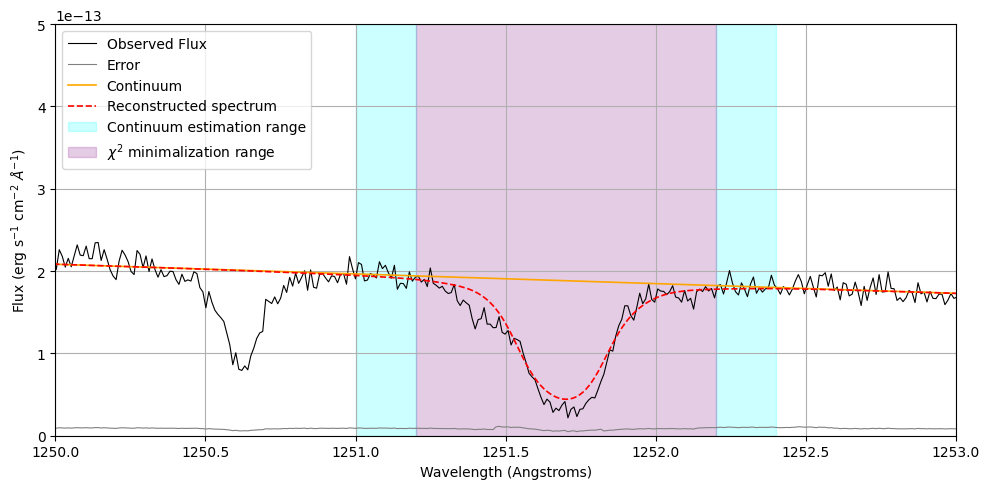

In [11]:
plt.figure(figsize = (10, 5))
plt.plot(example_wave, example_flux, label = "Observed Flux", color = "black", lw = 0.8)
plt.plot(example_wave, example_err, label = "Error", color = "grey", lw = 0.8)
plt.plot(example_wave, example_cont, label = "Continuum", color = "orange", lw = 1.2)
plt.plot(example_wave, example_best_model, label = "Reconstructed spectrum", color = "red", lw = 1.2, linestyle = "--")

y_max = 5e-13

for i in range(len(cont_windows)):
    bounds = cont_windows[i]
    if i == 0:
        plt.fill_between(bounds, 0, y_max, alpha = 0.2, label = "Continuum estimation range", color = "cyan")
    else: 
        plt.fill_between(bounds, 0, y_max, alpha = 0.2, color = "cyan")

for i in range(len(fit_windows)):
    bounds = fit_windows[i]
    if i == 0:
        plt.fill_between(bounds, 0, y_max, alpha = 0.2, label = r"$\chi^2$ minimalization range", color = "purple")
    else: 
        plt.fill_between(bounds, 0, y_max, alpha = 0.2, color = "purple")

row = df.iloc[0]

plt.xlabel("Wavelength (Angstroms)")
plt.ylabel(r"Flux (erg s$^{-1}$ cm$^{-2}$ $\AA^{-1}$)")
plt.xlim(1250, 1253)
plt.ylim(0, y_max)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

In [12]:
# END